In [26]:
"""!pip install git+https://github.com/thoglu/jammy_flows.git --no-deps
!pip install torchdiffeq
!pip install healpy
!pip install mhealpy"""

'!pip install git+https://github.com/thoglu/jammy_flows.git --no-deps\n!pip install torchdiffeq\n!pip install healpy\n!pip install mhealpy'

In [27]:
# Basic imports for data handling, modeling, plotting, and using Jammy Flows
import time
import sys
import os
import glob
import subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import jammy_flows
from scipy.stats import norm

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Add the path to your project directory
sys.path.append('/content/drive/My Drive/AdvDL/stellar-parameter-prediction')

from CNNhelper import get_normalized_data, denormalize, denormalize_std, normalize, train_model, evaluate_model



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# Load normalized data
DATA_PATH = '/content/drive/My Drive/AdvDL/stellar-parameter-prediction/data'

# get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)


In [29]:
# Defines a small CNN that maps spectra input to flow parameters
class TinyCNNEncoder(nn.Module):
    def __init__(self, latent_dimension):
        super(TinyCNNEncoder, self).__init__()

        # CNN architecture
        self.model = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, 5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten(),
            nn.Linear((spectra_length // 4) * 32, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dimension)  # Output size matches number of flow parameters
        )

    def forward(self, x):
        # Add a channel dimension before passing to CNN
        return self.model(x)

In [30]:
# Computes negative log-likelihood loss for training

def nf_loss(inputs, batch_labels, model):
    log_pdfs = model.log_pdf_evaluation(batch_labels, inputs)  # Evaluate log-probability under the predicted distribution
    loss = -log_pdfs.mean()  # Take negative mean to form loss
    return loss

In [59]:
class CombinedModel(nn.Module):
    """
    A combined model that integrates a normalizing flow with a CNN encoder.
    """

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        """
        Initializes the normalizing flow model.

        Parameters
        ----------
        encoder : callable
            A function or callable object that returns an encoder model. The encoder model
            should take the number of flow parameters as input and output the latent dimension.
        nf_type : str, optional
            The type of normalizing flow to use. Options are "diagonal_gaussian", "full_gaussian",
            and "full_flow". Default is "diagonal_gaussian".
        Raises
        ------
        Exception
            If an unknown `nf_type` is provided.
        Notes
        -----
        This method sets up a 3-dimensional probability density function (PDF) over Euclidean space (e3)
        using the specified normalizing flow type. The flow structure and options are configured based on
        the provided `nf_type`. The PDF is created using the `jammy_flows` library, and the number of flow
        parameters is determined and printed. The encoder is initialized with the number of flow parameters.
        """

        super().__init__()

        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
            opt_dict["t"]["cov_type"] = "diagonal"
            flow_defs = "t"
        elif (nf_type == "full_gaussian"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "t"
        elif (nf_type == "full_flow"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        else:
            raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 3d PDF (e3) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # latent dimension (output of the CNN encoder) is set to 128
        self.encoder = encoder(num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):
        """
        Evaluate the log probability density function (PDF) for the given target labels and input data.

        The normalizing flow parameters are predicted by the encoder network based on the input data.
        Then, the log PDF is evaluated at the position of the label.

        Parameters:
        -----------
        target_labels : torch.Tensor
            The target labels for which the log PDF is to be evaluated.
        input_data : torch.Tensor
            The input data to be encoded and used for evaluating the log PDF.
        Returns:
        --------
        log_pdf : torch.Tensor
            The evaluated log PDF for the given target labels and input data.
        """
        latent_intermediate = self.encoder(input_data)  # get the flow parameters from the CNN encoder

        if (self.nf_type == "full_flow"):
            # convert to double. Double precision is needed for the Gaussianization flow. This is for numerical stability.
            if fp64_on_cpu:  # MPS does not support double precision, therefore we need to run the flow on the CPU
                latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                target_labels = target_labels.cpu().to(torch.float64)
            else:
                latent_intermediate = latent_intermediate.to(torch.float64)
                target_labels = target_labels.to(torch.float64)

        # evaluate the log PDF at the target labels
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        """
        Sample new points from the PDF given input data.

        Parameters
        ----------
        flow_params : tensor
            Parameters for the normalizing flow, must be of shape (B, L) where B is the batch size and L is the latent dimension.
        samplesize_per_batchitem : int, optional
            Number of samples to draw per batch item. Defaults to 1000.

        Returns
        -------
        tensor
            A tensor of shape (B, S, D) where B is the batch dimension, S is the number of samples,
            and D is the dimension of the target space for the samples.
        """
        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        if (self.nf_type == "full_flow"):
            # convert to double
            if fp64_on_cpu: # MPS does not support double precision, therefore we need to run the flow on the CPU
                flow_params = flow_params.cpu().to(torch.float64)
            else:
                flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0] # get the batch size
        # sample from the normalizing flow
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
            samplesize_per_batchitem, dim=0), allow_gradients=False)

        # reshape the samples to be grouped by batch item
        reshaped_samples = repeated_samples[:, None, :].view(
            batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):
        """
        Perform a forward pass through the model, predicting the mean and standard deviation of the samples.

        Normalizing flows do not directly predict the target labels. Instead, they predict the parameters of the flow that
        transforms the base distribution to the target distribution. Often, we still want to predict the target labels.
        Then, we can sample from the distribution and form the mean of the samples and their standard deviations.
        This is what this function does.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor.
        Returns
        -------
        torch.Tensor
            A tensor of size (B, D*2) where the first half (size D) are the means,
            the second half (another D) are the standard deviations.
        """
        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename=None, samplesize=1000, batch_index=0, truth=None):
        """
        Visualizes the probability density function (PDF) of the given input data using a normalizing flow model.

        The function generates samples from the normalizing flow (using the sample() function)
        and plots the histogram of the samples together with a Gaussian approximation.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor from which to pick one batch item for visualization.
        filename : str
            The filename where the resulting plot will be saved.
        samplesize : int, optional
            The number of samples to generate for the PDF visualization (default is 10000).
        batch_index : int, optional
            The index of the batch item to visualize (default is 0).
        truth : torch.Tensor, optional
            The true values of the labels, used for comparison in the plot (default is None).

        Returns
        -------
        None
        """
        # pick out one input from batch
        input_bitem = input_data[batch_index:batch_index+1]

        # get the flow parameters (by passing the input data through the CNN encoder network)
        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow (i.e. samples are drawn from the base distribution and transformed by the flow
        # using the change-of-variable formula)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)
        # the rest of the code is just plotting.

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        # so we calculate the mean and std of the samples
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(3, 1)
        for dim_ind in range(3):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")

            # plot the true value if it is given
            if (truth is not None):
                true_value = truth[dim_ind].cpu().item()
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if (dim_ind == 0):
                axdict[dim_ind].legend()


        plt.show()

In [32]:
#Model Initialization and Device Handling
fp64_on_cpu = False
nf_type = "full_flow"  # Options: "diagonal_gaussian", "full_gaussian", "full_flow"
model = CombinedModel(TinyCNNEncoder, nf_type=nf_type)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
if nf_type == "full_flow" and device.type == "mps":
    fp64_on_cpu = True
print(f"Using device: {device}, performing fp64 on CPU: {fp64_on_cpu}")
model.to(device)

sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  lower_bound_for_widths  wit

CombinedModel(
  (pdf): pdf(
    (layer_list): ModuleList(
      (0): ModuleList(
        (0-2): 3 x gf_block()
        (3): mvn_block()
      )
    )
    (mlp_predictors): ModuleList(
      (0): None
    )
  )
  (encoder): TinyCNNEncoder(
    (model): Sequential(
      (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Flatten(start_dim=1, end_dim=-1)
      (7): Linear(in_features=131072, out_features=128, bias=True)
      (8): ReLU()
      (9): Linear(in_features=128, out_features=306, bias=True)
    )
  )
)

In [33]:
#Create Dataloaders for Training and Validation
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)
dataset = TensorDataset(spectra_tensor, labels_tensor)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)

In [34]:
# Define training arguments
learning_rate = 8e-6
num_epochs = 200
patience = 10
model_name = "normalizing_flow_model"

# Train the model
train_losses, val_losses, best_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=nf_loss,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    patience=patience,
    device=device,
    plot_fn=None,  # You can plug in a plot function later
    plot_interval=10,
    model_name=model_name
)


Epoch [1/200], Step [250/251], Loss: 0.0859
Epoch [1/200], Train Loss: 0.9610, Val Loss: -0.1096, Time: 11.24 seconds
Epoch [2/200], Step [250/251], Loss: -0.3682
Epoch [2/200], Train Loss: -0.3781, Val Loss: -0.5839, Time: 11.18 seconds
Epoch [3/200], Step [250/251], Loss: -0.9647
Epoch [3/200], Train Loss: -0.8738, Val Loss: -1.1530, Time: 11.15 seconds
Epoch [4/200], Step [250/251], Loss: -1.0399
Epoch [4/200], Train Loss: -1.2819, Val Loss: -1.4601, Time: 11.20 seconds
Epoch [5/200], Step [250/251], Loss: -2.3113
Epoch [5/200], Train Loss: -1.6814, Val Loss: -1.6698, Time: 11.23 seconds
Epoch [6/200], Step [250/251], Loss: -2.3248
Epoch [6/200], Train Loss: -2.0894, Val Loss: -2.1935, Time: 11.25 seconds
Epoch [7/200], Step [250/251], Loss: -1.7111
Epoch [7/200], Train Loss: -2.3212, Val Loss: -2.1380, Time: 11.19 seconds
Epoch [8/200], Step [250/251], Loss: -2.0228
Epoch [8/200], Train Loss: -2.6479, Val Loss: -2.0823, Time: 11.19 seconds
Epoch [9/200], Step [250/251], Loss: -3.17

In [38]:
#Model eval
predictions, targets, first_batch_spectra, first_batch_labels = evaluate_model(
    model=model,
    test_loader=val_loader,
    loss_function=nf_loss,
    device=device
)


Evaluating model on the test dataset...
Final Test Loss: -3.8979


In [40]:
print(model.encoder.model)


Sequential(
  (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (4): ReLU()
  (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=131072, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=306, bias=True)
)


Flow 1 - Example 0


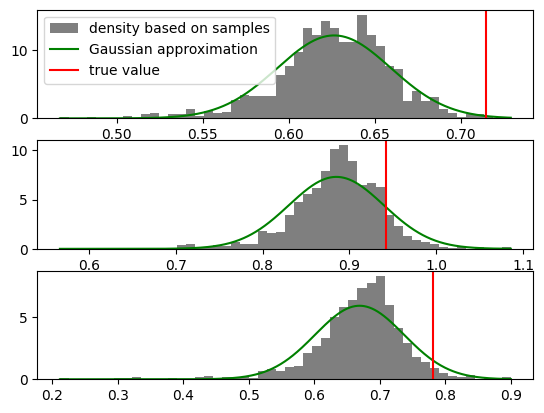

AttributeError: 'NoneType' object has no attribute 'write'

<Figure size 640x480 with 0 Axes>

In [86]:
#Prepare batch input and labels for flow 1
spectra_batch_1 = first_batch_spectra.to(device)  # keep shape [B, 1, 16384]
labels_batch_1 = first_batch_labels.to(device)

# Visualize the predictive PDFs for a few examples
for i in range(3):
    print(f"Flow 1 - Example {i}")
    model.visualize_pdf(spectra_batch_1, filename=None, batch_index=i, truth=labels_batch_1[i])






In [63]:
import numpy as np
import matplotlib.pyplot as plt

def compute_coverage_and_plot(samples, true_values, intervals=[0.68, 0.95], label_names=None):
    B, S, D = samples.shape
    sorted_samples = np.sort(samples.cpu().numpy(), axis=1)
    truths_np = true_values.cpu().numpy()
    coverage_results = {}

    fig, axes = plt.subplots(1, D, figsize=(5 * D, 4))
    for d in range(D):
        axis = axes[d] if D > 1 else axes
        dim_coverages = []
        for p in intervals:
            low_idx = int((1.0 - p) / 2.0 * S)
            high_idx = int((1.0 + p) / 2.0 * S)
            covered = (truths_np[:, d] >= sorted_samples[:, low_idx, d]) & \
                      (truths_np[:, d] <= sorted_samples[:, high_idx, d])
            coverage = np.mean(covered)
            dim_coverages.append(coverage)

        axis.plot([int(p*100) for p in intervals], dim_coverages, marker="o")
        axis.axhline(y=1.0, color="gray", linestyle="--", linewidth=1)
        axis.set_ylim(0, 1.05)
        axis.set_xlabel("Credible Interval (%)")
        axis.set_ylabel("Empirical Coverage")
        axis.set_title(label_names[d] if label_names else f"Target {d}")
        coverage_results[d] = dim_coverages

    plt.tight_layout()
    plt.show()
    return coverage_results


In [67]:
# Use the first batch of spectra and labels returned from evaluate_model
spectra_batch = first_batch_spectra.to(device)  # shape [B, 1, L]
labels_batch = first_batch_labels.to(device)    # shape [B, 3]

# Sample from the learned flow
with torch.no_grad():
    flow_params = model.encoder(spectra_batch)  # flow parameters per input
    flow_samples = model.sample(flow_params, samplesize_per_batchitem=1000)  # shape: [B, 1000, 3]


In [73]:
# Get one batch from your evaluation (you already have this)
spectra_batch = first_batch_spectra.to(device)  # [B, 1, L]
labels_batch = first_batch_labels.to(device)    # [B, 3]

# Sample from the model
with torch.no_grad():
    flow_params = model.encoder(spectra_batch)
    flow_samples = model.sample(flow_params, samplesize_per_batchitem=1000)  # [B, 1000, 3]

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_2d_joint(samples, true_values, label_names=None):
    """
    Plot all pairwise 2D joint KDEs of sampled predictions with true values.

    Parameters
    ----------
    samples : torch.Tensor of shape [B, S, D]
        Predicted samples from the normalizing flow. B = batch size, S = samples per input, D = number of predicted dimensions.
    true_values : torch.Tensor of shape [B, D]
        Ground truth values for each input.
    label_names : list of str, optional
        Names of the predicted dimensions for axis labeling. If None, generic labels are used.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    B, S, D = samples.shape
    fig, axes = plt.subplots(D, D, figsize=(4 * D, 4 * D))
    sample_np = samples.cpu().numpy()
    truth_np = true_values.cpu().numpy()

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i == j:
                # Diagonal: 1D marginal histogram of samples
                ax.hist(sample_np[:, :, i].flatten(), bins=50, color='gray', alpha=0.7, density=True)
                ax.axvline(truth_np[:, i].mean(), color='red', label="Mean of true values")
                ax.set_xlabel(label_names[i] if label_names else f"Dimension {i}")
                ax.set_ylabel("Density")
                ax.set_title(f"Marginal distribution of {label_names[i] if label_names else f'Dim {i}'}")
            else:
                # Off-diagonal: 2D KDE plot
                joint = sample_np[:, :, [j, i]].reshape(-1, 2)
                truths_2d = truth_np[:, [j, i]]
                sns.kdeplot(
                    x=joint[:, 0], y=joint[:, 1], ax=ax,
                    fill=True, cmap="Blues", thresh=0.01, levels=100
                )
                ax.scatter(truths_2d[:, 0], truths_2d[:, 1], color="red", s=10, label="True values")
                ax.set_xlabel(label_names[j] if label_names else f"Dim {j}")
                ax.set_ylabel(label_names[i] if label_names else f"Dim {i}")

            if i == 0 and j == 0:
                ax.legend(loc='upper right')

    plt.suptitle("Joint and Marginal Distributions of Predicted Samples vs True Values", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()






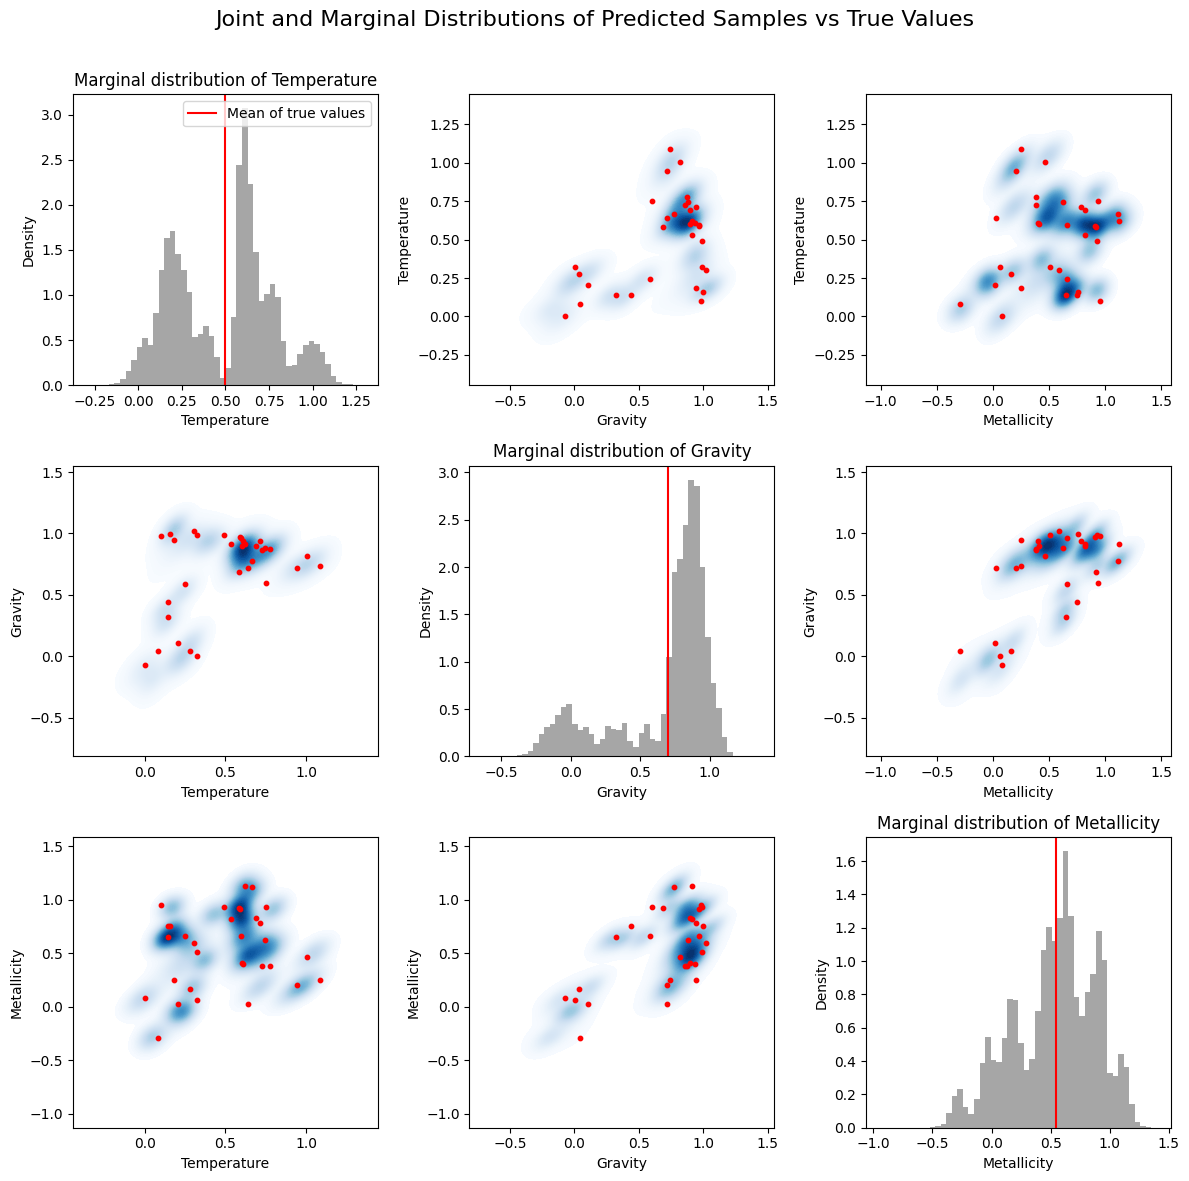

In [74]:
plot_all_2d_joint(flow_samples, labels_batch, label_names=["Temperature", "Gravity", "Metallicity"])


In [75]:
# ----------------------------
# 2. Normalizing Flow with FULL 3D Gaussian
# ----------------------------

# Define model using a full 3D Gaussian (mean + full covariance matrix)
model_full_gaussian = CombinedModel(TinyCNNEncoder, nf_type="full_gaussian").to(device)

# Train this model using the same training loop
train_losses_full_gaussian, val_losses_full_gaussian, best_model_full_gaussian = train_model(
    model=model_full_gaussian,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=nf_loss,
    learning_rate=8e-6,
    num_epochs=200,
    patience=10,
    device=device,
    plot_fn=None,
    model_name="nf_full_gaussian"
)

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  full
The normalizing flow has  9  parameters...
Epoch [1/200], Step [250/251], Loss: 0.1774
Epoch [1/200], Train Loss: 0.8239, Val Loss: 0.1392, Time: 7.98 seconds
Epoch [2/200], Step [250/251], Loss: 0.6445
Epoch [2/200], Train Loss: -0.1661, Val Loss: -0.5355, Time: 5.06 seconds
Epoch [3/200], Step [250/251], Loss: -1.2605
Epoch [3/200], Train Loss: -0.9030, Val Loss: -1.1327, Time: 5.11 seconds
Epoch [4/200], Step [250/251], Loss: -2.0797
Epoch [4/200], Train Loss: -1.4537, Val Loss: -1.6459, Time: 5.07 seconds
Epoch [5/200], Step [250/251], Loss: -1.9851
Epoch [5/200], Train Loss: -1.7950, Val Loss: -1.9072, Time: 5.11 seconds
Epoch [6/200], Step [250/251], Loss: -1.8628
Epoch [6/200], Train Loss: -2.0185, Val Loss: -2.0130, Time: 5.06 seconds
Epoch [7/200], Step [250/251], Loss: -1.8759
Epoch [7/200], Train Loss: -2.1549, Val Loss: -2.2163, Time: 5.08 seconds
Epoch [8/200], Step [250/251],

In [76]:
# Evaluate the full 3D Gaussian model
predictions_full_gaussian, targets_full_gaussian, first_spectra_fg, first_labels_fg = evaluate_model(
    model_full_gaussian,
    test_loader=val_loader,
    loss_function=nf_loss,
    device=device
)

Evaluating model on the test dataset...
Final Test Loss: -2.7064


Visualizing predictive PDFs for Flow 2: Full Gaussian
Flow 2 (Full Gaussian) - Example 0


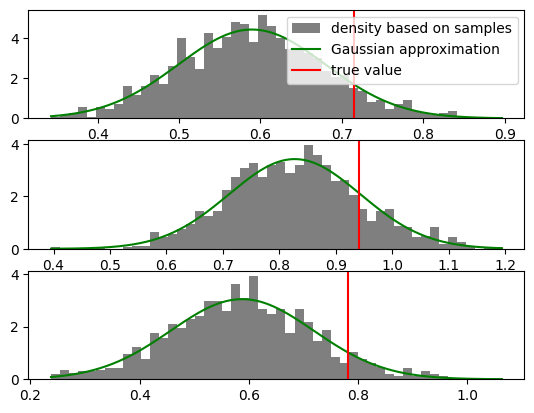

Flow 2 (Full Gaussian) - Example 1


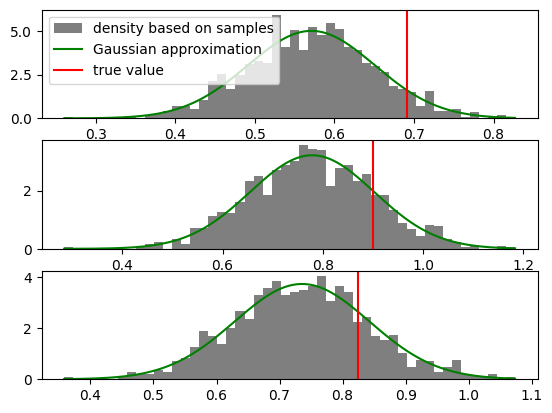

Flow 2 (Full Gaussian) - Example 2


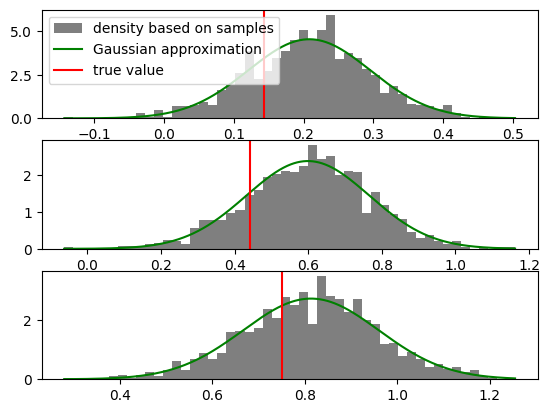

In [78]:
print("Visualizing predictive PDFs for Flow 2: Full Gaussian")

# Prepare batch input and labels for Flow 2
spectra_batch_2 = first_batch_spectra.to(device)       # shape [B, 1, L]
labels_batch_2 = first_batch_labels.to(device)         # shape [B, 3]

# Visualize the predictive PDFs for a few examples
for i in range(3):
    print(f"Flow 2 (Full Gaussian) - Example {i}")
    model_full_gaussian.visualize_pdf(spectra_batch_2, filename=None, batch_index=i, truth=labels_batch_2[i])


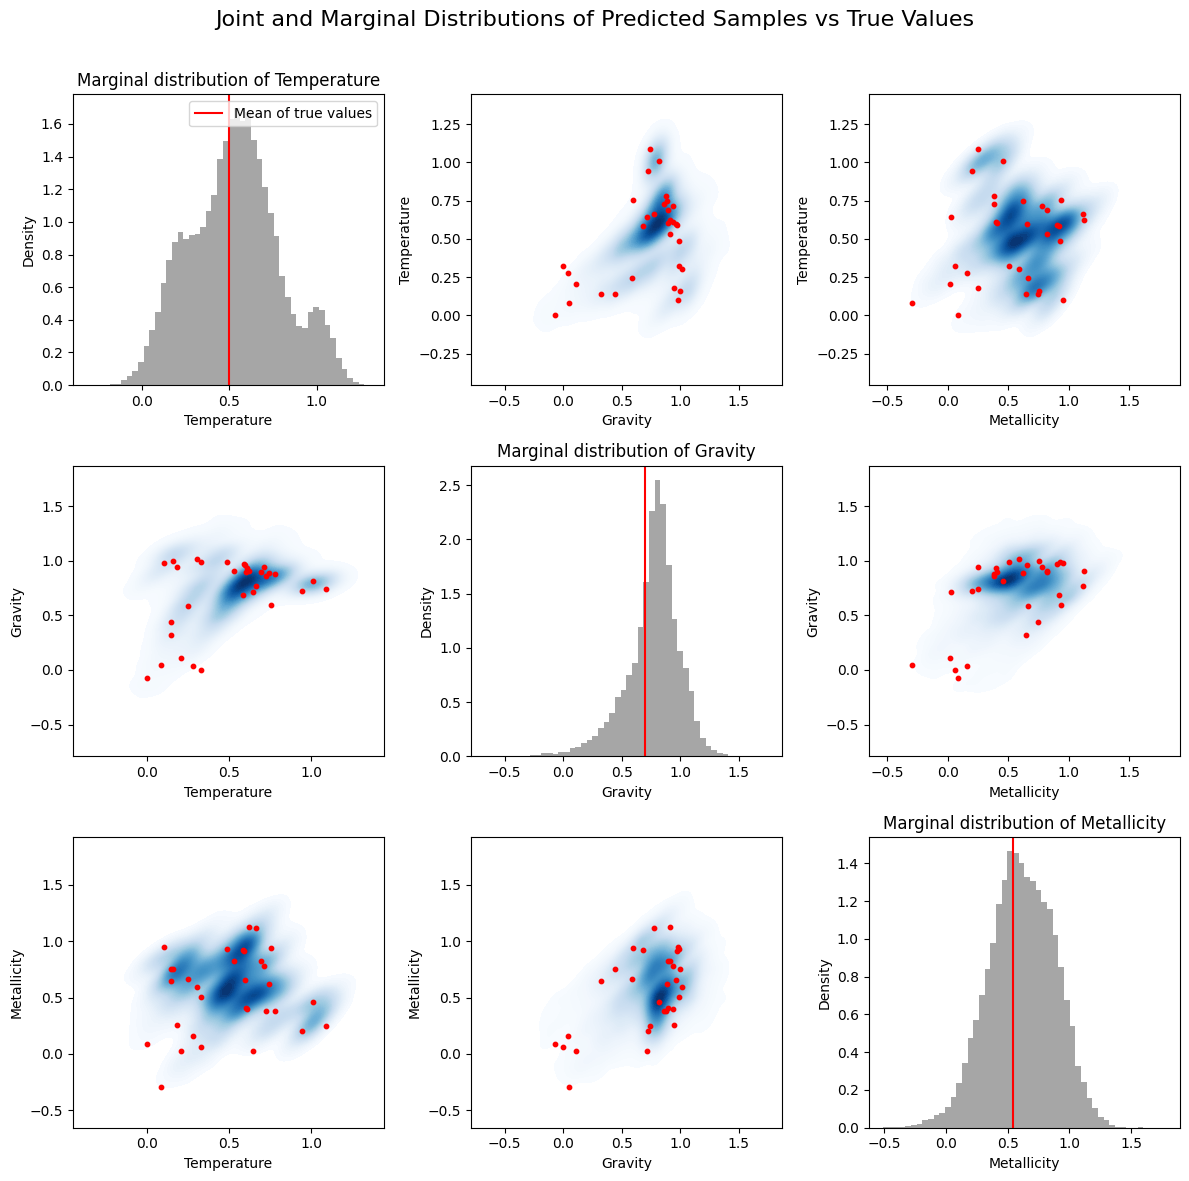

In [79]:
# Sample from the model
flow_params_fg = model_full_gaussian.encoder(first_spectra_fg)
flow_samples_fg = model_full_gaussian.sample(flow_params_fg, samplesize_per_batchitem=1000)

# Plot 2D joint density plots
plot_all_2d_joint(flow_samples_fg, first_labels_fg, label_names=["Temperature", "Gravity", "Metallicity"])



In [81]:
# ----------------------------
# 3. Full Normalizing Flow (Gaussianization Flows + Affine Flow)
# ----------------------------

# This version uses several Gaussianization layers followed by an affine flow.
model_full_flow = CombinedModel(TinyCNNEncoder, nf_type="full_flow").to(device)

# Train the full flow model
train_losses_full_flow, val_losses_full_flow, best_model_full_flow = train_model(
    model=model_full_flow,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=nf_loss,
    learning_rate=8e-5,
    num_epochs=200,
    patience=20,
    device=device,
    plot_fn=None,
    model_name="nf_full_flow"
)

sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  lower_bound_for_widths  wit

In [82]:
# Evaluate full flow model
predictions_full_flow, targets_full_flow, first_spectra_ff, first_labels_ff = evaluate_model(
    model_full_flow,
    test_loader=val_loader,
    loss_function=nf_loss,
    device=device
)

Evaluating model on the test dataset...
Final Test Loss: -2.1187


Visualizing predictive PDFs for Flow 3: Gaussianization Flow
Flow 3 (Full Flow) - Example 0


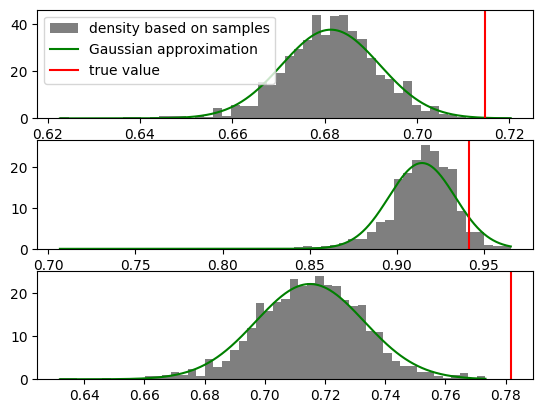

Flow 3 (Full Flow) - Example 1


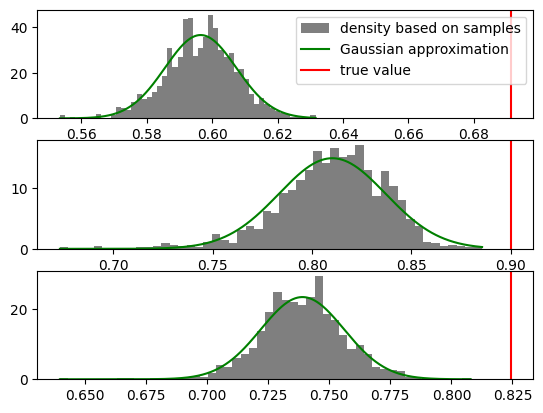

Flow 3 (Full Flow) - Example 2


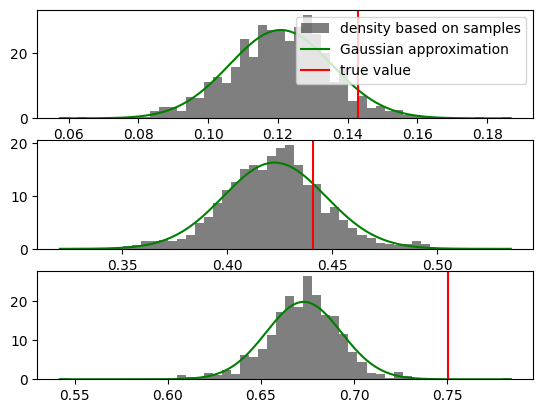

In [84]:
print("Visualizing predictive PDFs for Flow 3: Gaussianization Flow")

# Prepare batch input and labels for Flow 3
spectra_batch_3 = first_batch_spectra.to(device)
labels_batch_3 = first_batch_labels.to(device)

# Visualize the predictive PDFs for a few examples
for i in range(3):
    print(f"Flow 3 (Full Flow) - Example {i}")
    model_full_flow.visualize_pdf(spectra_batch_3, filename=None, batch_index=i, truth=labels_batch_3[i])


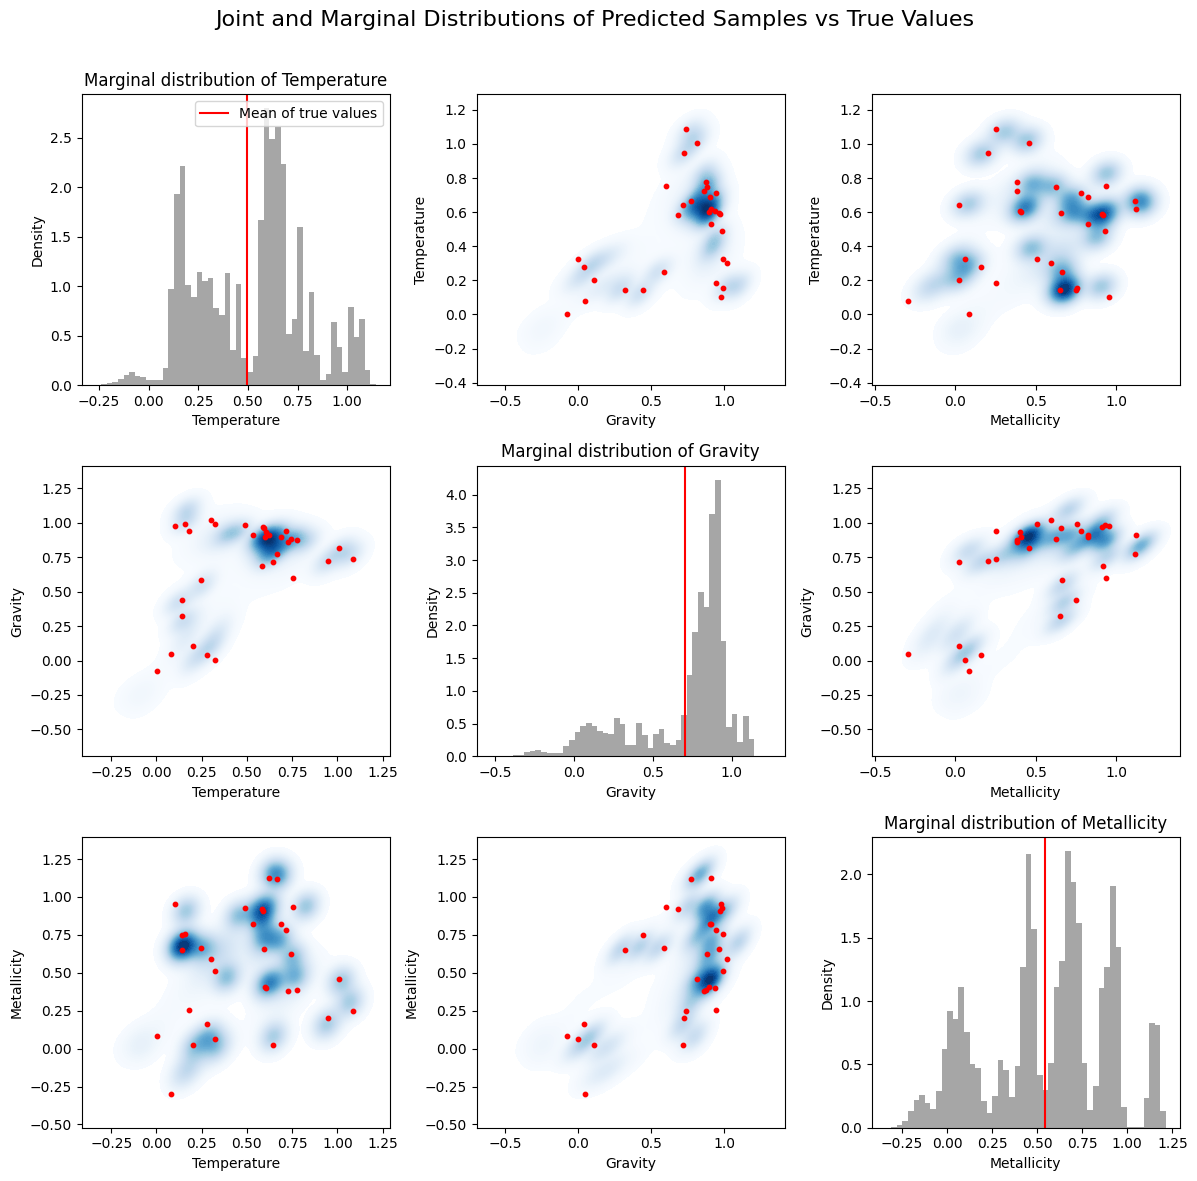

In [85]:
# Sample from full flow
flow_params_ff = model_full_flow.encoder(first_spectra_ff)
flow_samples_ff = model_full_flow.sample(flow_params_ff, samplesize_per_batchitem=1000)

# Plot 2D joint density plots for full flow
plot_all_2d_joint(flow_samples_ff, first_labels_ff, label_names=["Temperature", "Gravity", "Metallicity"])
